# 301 Regression

View more, visit my tutorial page: https://morvanzhou.github.io/tutorials/
My Youtube Channel: https://www.youtube.com/user/MorvanZhou

Dependencies:
* torch: 1.0.0
* matplotlib

https://ptorch.com/docs/4/pytorch-video-regression

In [12]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [13]:
torch.manual_seed(1)    # reproducible

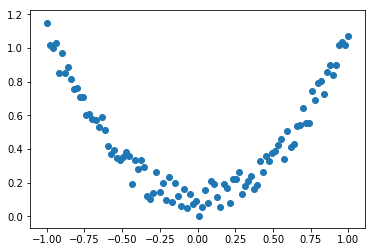

In [14]:
# unsqueeze() 将一维数据变成二维的
x = torch.unsqueeze(torch.linspace(-1, 1, 100), dim=1)  # x data (tensor), shape=(100, 1)
y = x.pow(2) + 0.2*torch.rand(x.size())                 # noisy y data (tensor), shape=(100, 1)

plt.scatter(x.numpy(), y.numpy())
plt.show()

建立一个神经网络，可以直接运用 torch 中的体系。先定义每层的属性(init())，然后再根据前向传递搭建(forward(x))层与层的关系连接。

In [15]:
class Net(torch.nn.Module):
    def __init__(self, n_feature, n_hidden, n_output):
        super(Net, self).__init__()
        self.hidden = torch.nn.Linear(n_feature, n_hidden)   # hidden layer
        self.predict = torch.nn.Linear(n_hidden, n_output)   # output layer

    def forward(self, x): # x为输入数据
        x = F.relu(self.hidden(x))      # activation function for hidden layer
        x = self.predict(x)             # linear output
        return x

In [16]:
net = Net(n_feature=1, n_hidden=10, n_output=1)     # define the network
print(net)  # net architecture

Net(
  (hidden): Linear(in_features=1, out_features=10, bias=True)
  (predict): Linear(in_features=10, out_features=1, bias=True)
)


In [17]:
# net.parameters() 包含所有需要学习的参数
optimizer = torch.optim.SGD(net.parameters(), lr=0.2)
loss_func = torch.nn.MSELoss()  # this is for regression mean squared loss

使用交叉熵损失函数时会自动把label转化成onehot，所以不用手动转化，而使用MSE需要手动转化成onehot编码。

转化方法为：https://discuss.pytorch.org/t/convert-int-into-one-hot-format/507/3

回归常使用的损失函数为`mean squared loss`，分类常使用的损失函数为`cross entropy loss`。

In [18]:
plt.ion()   # something about plotting

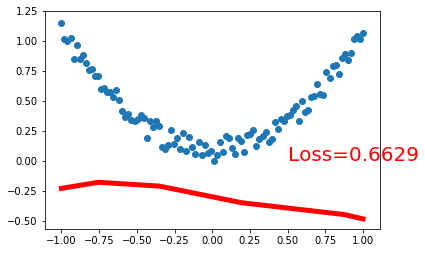

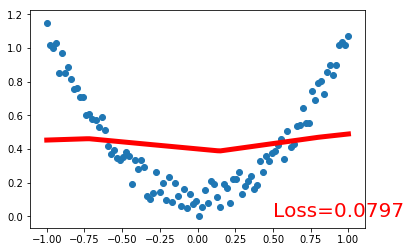

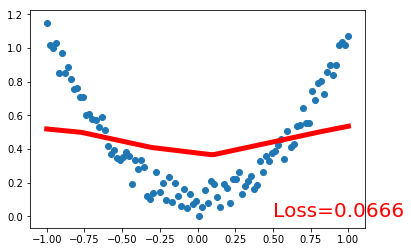

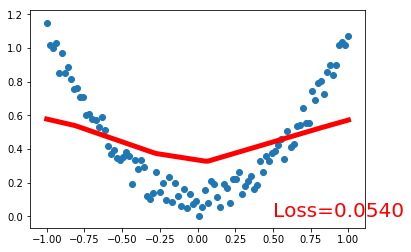

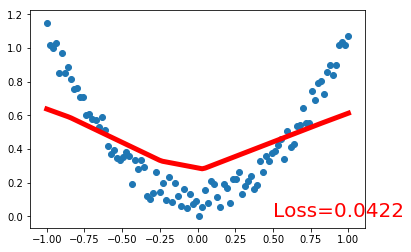

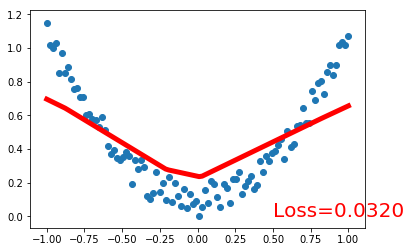

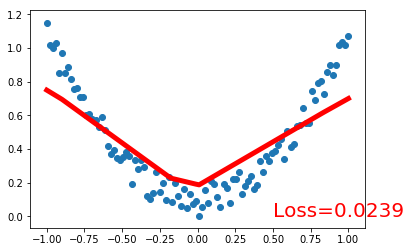

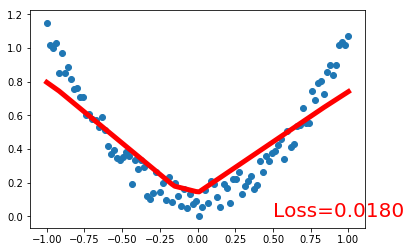

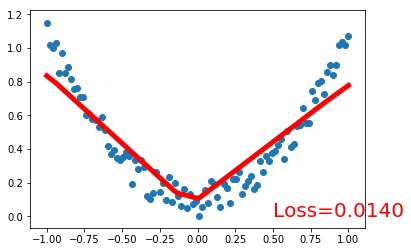

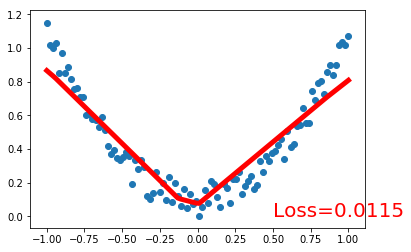

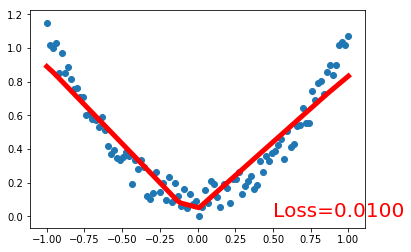

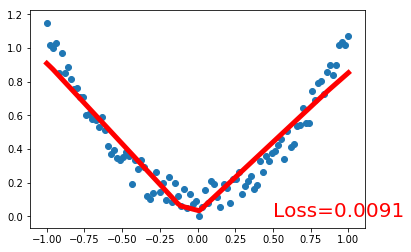

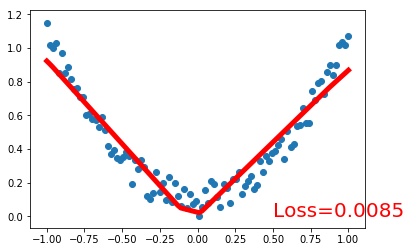

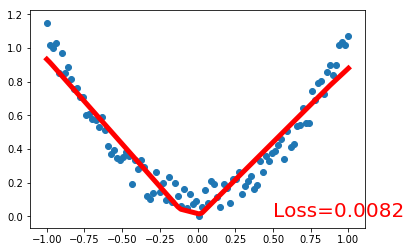

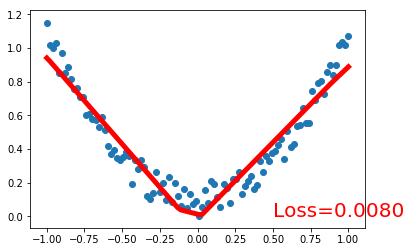

In [19]:
for t in range(150):
    # 调用了Net类的__CALL__方法
    prediction = net(x)     # input x and predict based on x

    loss = loss_func(prediction, y)     # order must be (1. nn output, 2. target)

    optimizer.zero_grad()   # clear gradients for next train
    loss.backward()         # backpropagation, compute gradients
    optimizer.step()        # 使用梯度优化参数

    if t % 10 == 0:
        # plot and show learning process
        plt.cla()
        plt.scatter(x.numpy(), y.numpy())
        plt.plot(x.numpy(), prediction.detach().numpy(), 'r-', lw=5)
        plt.text(0.5, 0, 'Loss=%.4f' % loss.detach().numpy(), fontdict={'size': 20, 'color':  'red'})
        plt.show()
        plt.pause(0.1)

plt.ioff()